In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR , SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor , RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler , LabelEncoder 
from sklearn.metrics import root_mean_squared_error , r2_score , accuracy_score , precision_score , confusion_matrix , recall_score , f1_score, roc_curve , auc , mean_squared_error
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score , roc_auc_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

## -----------------------------------------------------------------------------------------------------------------
##                                          Phase 1 
## ----------------------------------------------------------------------------------------------------------------- 

In [2]:
data = pd.read_csv('database_24_25.csv')
print(data.head())

          Player   Tm  Opp Res     MP  FG  FGA    FG%  3P  3PA  ...  TOV  PF  \
0   Jayson Tatum  BOS  NYK   W  30.30  14   18  0.778   8   11  ...    1   1   
1  Anthony Davis  LAL  MIN   W  37.58  11   23  0.478   1    3  ...    1   1   
2  Derrick White  BOS  NYK   W  26.63   8   13  0.615   6   10  ...    0   1   
3   Jrue Holiday  BOS  NYK   W  30.52   7    9  0.778   4    6  ...    0   2   
4  Miles McBride  NYK  BOS   L  25.85   8   10  0.800   4    5  ...    1   1   

   PTS  GmSc        Data  successful_steals  points per mintues  shots_made  \
0   37  38.1  2024-10-22                0.0            1.221122          23   
1   36  34.0  2024-10-22                0.0            0.957956          25   
2   24  22.4  2024-10-22                0.0            0.901239          16   
3   18  19.5  2024-10-22               -1.0            0.589777          11   
4   22  17.8  2024-10-22                0.0            0.851064          14   

   attemped_shots  shooting percentage  
0  

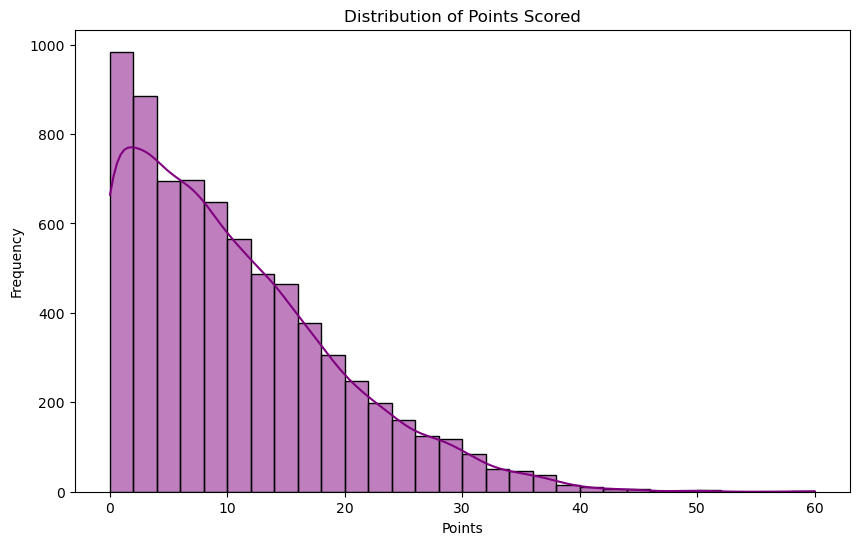

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(data['PTS'], bins=30, kde=True, color='purple')
plt.title('Distribution of Points Scored')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.show()

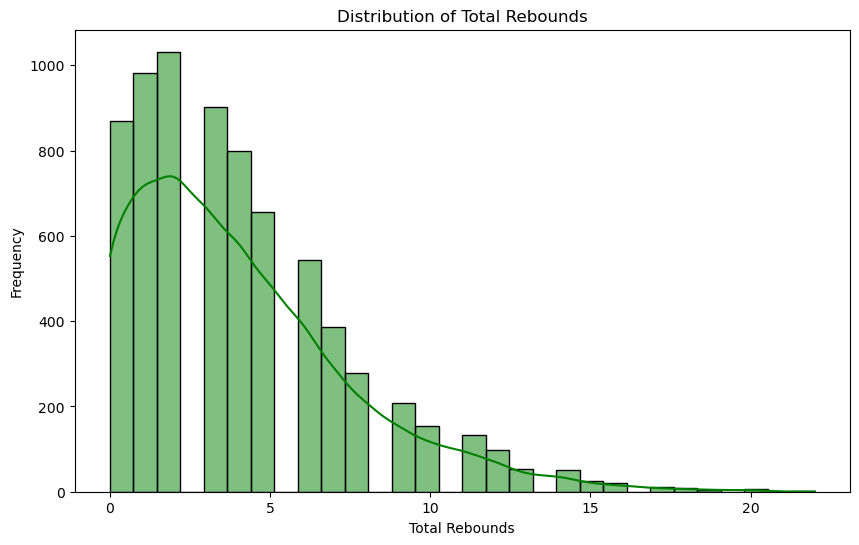

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data['TRB'], bins=30, kde=True, color='green')
plt.title('Distribution of Total Rebounds')
plt.xlabel('Total Rebounds')
plt.ylabel('Frequency')
plt.show()

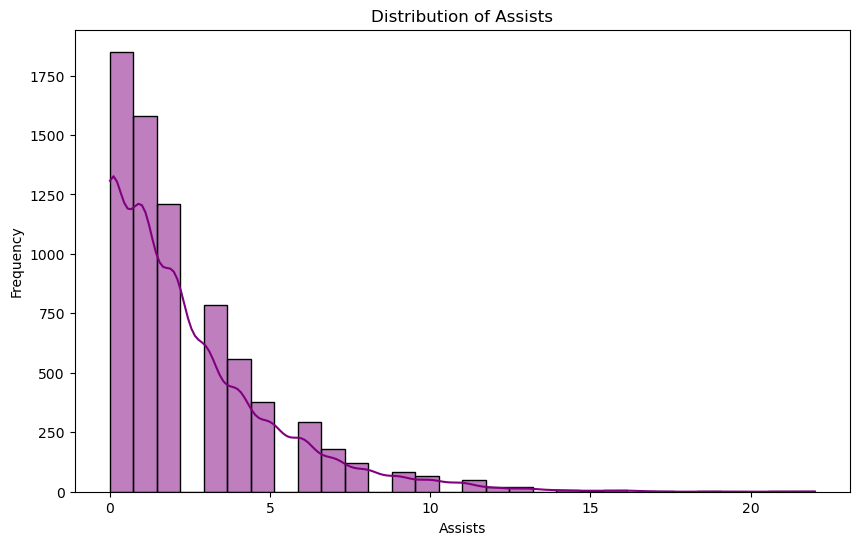

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data['AST'], bins=30, kde=True, color='purple')
plt.title('Distribution of Assists')
plt.xlabel('Assists')
plt.ylabel('Frequency')
plt.show()

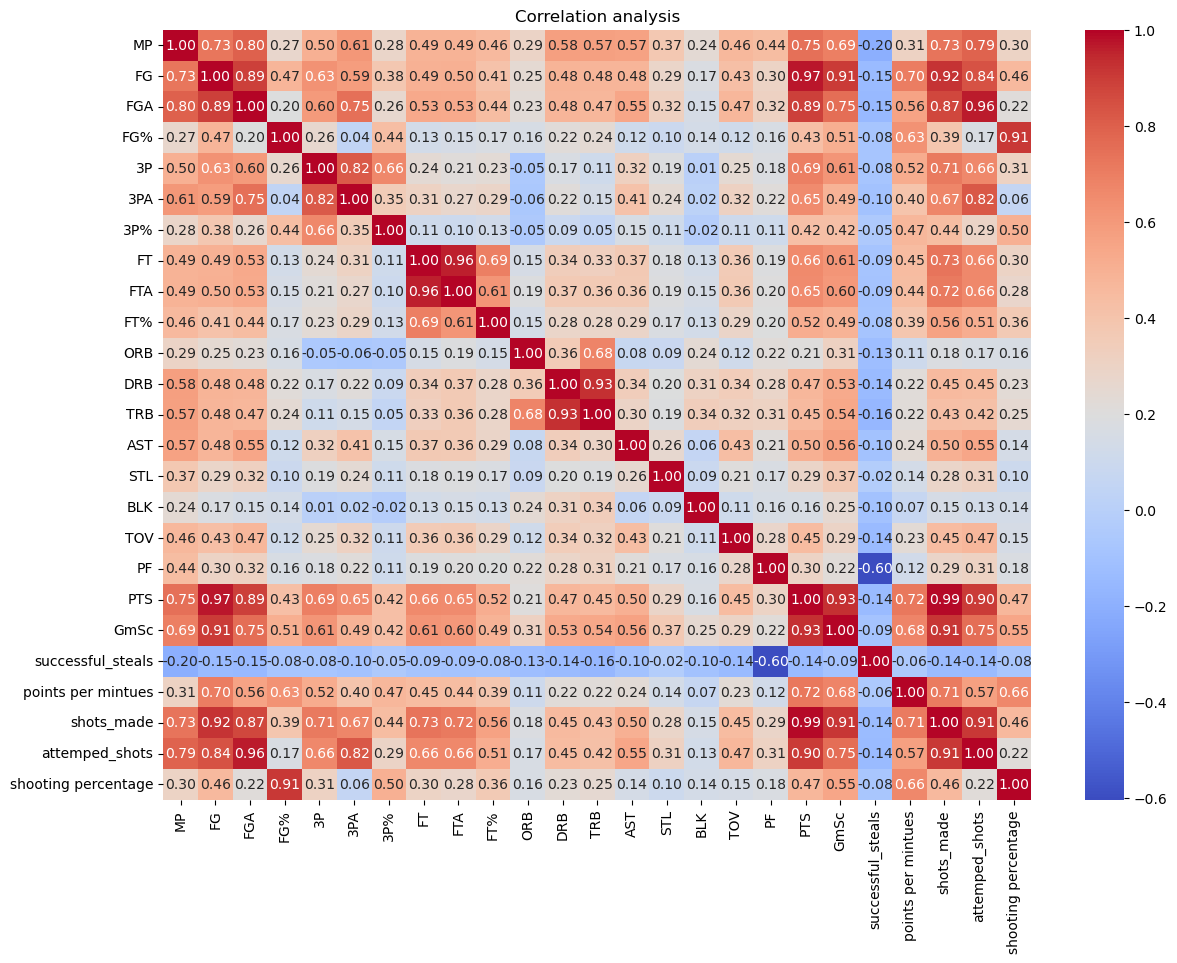

In [6]:
numeric_df = data.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation analysis')
plt.show()

In [7]:
data.isnull().sum()

Player                 0
Tm                     0
Opp                    0
Res                    0
MP                     0
FG                     0
FGA                    0
FG%                    0
3P                     0
3PA                    0
3P%                    0
FT                     0
FTA                    0
FT%                    0
ORB                    0
DRB                    0
TRB                    0
AST                    0
STL                    0
BLK                    0
TOV                    0
PF                     0
PTS                    0
GmSc                   0
Data                   0
successful_steals      0
points per mintues     2
shots_made             0
attemped_shots         0
shooting percentage    0
dtype: int64

## -----------------------------------------------------------------------------------------------------------------
##                                          Phase 2:task1
## ----------------------------------------------------------------------------------------------------------------- 

In [8]:
## i used np.where to add condition because there is values that is zero in STL so if the value of stl 0 the divison will not happen his value will be still 0 
##feature 1
data["successful_steals"]= np.where(data["STL"] !=0 ,(data["STL"] - data["PF"]) / data["STL"],0 )
print("Created : successful_steals ")
##here there no 0 value in MP so we can divied noraml 
data["points per mintues"] = data["PTS"] / data["MP"]
print("Created : points per mintues ")
#feature 3 
data["shots_made"]=  ( data["FG"] + data["3P"] + data["FT"] )
data["attemped_shots"] = (data["FGA"] + data["3PA"] + data["FTA"])
##i used np.where because there is rows has values 0 in the attemped so i dont want error in the dividing because the 0
data["shooting percentage"] = np.where(data["attemped_shots"]!=0 , (data["shots_made"] / data["attemped_shots"]) , 0)

print("Created : shooting percentage ")

Created : successful_steals 
Created : points per mintues 
Created : shooting percentage 


In [9]:
#if the result is 1 means (the player steals the boll with no mistakes) but if its 0 (he steal the boll with making mistakes) and if its -num (means he has mistakes more than stealing the boll )
# SO 1 MEANS STRONG defense , 0 means NORMAL defense , and - num means BAD defense

data["successful_steals"].head(10)

0    0.0
1    0.0
2    0.0
3   -1.0
4    0.0
5    0.0
6   -2.0
7    0.0
8    0.0
9   -1.0
Name: successful_steals, dtype: float64

In [10]:
data["shooting percentage"].head(10)
# 0.74 means the player has 75% successful shoting in the match

0    0.741935
1    0.609756
2    0.640000
3    0.733333
4    0.777778
5    0.500000
6    0.516129
7    0.666667
8    0.550000
9    0.583333
Name: shooting percentage, dtype: float64

In [11]:
data["points per mintues"].head(10)
#if the result more then 1 (1.2-1.5,.1.8) this means the player makes more then 1 point in the minute and it means he is point maker(perfect player)
#if 1- 0.7 good player
# if 0.6 - 0.4 normal player not Scorer
# if 0.3>=result this means the player is playing at defense 

0    1.221122
1    0.957956
2    0.901239
3    0.589777
4    0.851064
5    0.513113
6    0.769231
7    0.367959
8    0.466200
9    0.421779
Name: points per mintues, dtype: float64

In [12]:
y = data['PTS']
X = data.drop(['PTS'], axis=1)

# drop samples with missing values
X = X.dropna()

# use the same samples
y = y[X.index]  



# List of categorical columns
cat_cols = ['Player', 'Tm', 'Opp', 'Res', 'Data']

# Drop categorical columns 
X_no_cat = X.drop(columns=cat_cols)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_no_cat, y, test_size=0.20, random_state=42
)

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [13]:
## random forest regressor 
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300, 400, 500],
}
 
# GridSearchCV using regression scoring (MSE or R²)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
 
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'n_estimators': [50, 100, 150, 200, 300, 400, 500]},
             scoring='neg_mean_squared_error')

In [14]:
print("Best n_estimators:", grid.best_params_['n_estimators'])
print("Best CV score (neg MSE):", grid.best_score_)
 
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test_scaled)
 
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# R² score
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R² Score:", r2)

Best n_estimators: 100
Best CV score (neg MSE): -0.027432530667878235
RMSE: 0.09575214698549546
R² Score: 0.9998759097788917


In [26]:
## Support Vector Regressor
svr = SVR(kernel="linear", C=1)
svr.fit(X_train_scaled, y_train)

y_pred = svr.predict(X_test_scaled)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error: {rmse}  and the R2 score is : {r2}")

Root Mean Squared Error: 0.5108309341985905  and the R2 score is : -0.04403531392848348


In [16]:
## MLP model
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2 layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
 
 
# train
 
 
mlp.fit(X_train_scaled, y_train)
 
##Predict
 
y_pred = mlp.predict(X_test_scaled)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
 
print("====== MLP Regression Results ======")
print("RMSE:", rmse)
print("R² Score:", r2)

====== MLP Regression Results ======
RMSE: 0.0576020675445096
R² Score: 0.9999550927292725


## -----------------------------------------------------------------------------------------------------------------
##                                          Phase 2:   task2
## ----------------------------------------------------------------------------------------------------------------- 

In [14]:
# Calculate per game average
per_game_avg = data.groupby("Player").mean(numeric_only=True)

# Calculate Win Rate
winrate = data.groupby('Player')['Res'].apply(lambda x: (x == 'W').sum() / len(x))
per_game_avg['WinRate'] = winrate.values

print(per_game_avg.head())


                      MP        FG       FGA       FG%        3P       3PA  \
Player                                                                       
A.J. Green     20.531000  2.750000  5.750000  0.462250  2.450000  5.300000   
AJ Johnson      2.140000  0.600000  1.200000  0.333400  0.200000  0.200000   
Aaron Gordon   30.341000  5.300000  9.600000  0.546400  1.600000  3.000000   
Aaron Holiday   8.841538  1.307692  2.692308  0.459000  0.923077  2.000000   
Aaron Nesmith  22.705000  3.166667  6.000000  0.548167  1.000000  1.833333   

                  3P%        FT       FTA       FT%  ...       TOV        PF  \
Player                                               ...                       
A.J. Green     0.4295  0.250000  0.300000  0.125000  ...  0.600000  2.050000   
AJ Johnson     0.2000  0.000000  0.000000  0.000000  ...  0.400000  0.000000   
Aaron Gordon   0.4714  2.900000  3.700000  0.646700  ...  1.400000  1.600000   
Aaron Holiday  0.4000  0.384615  0.538462  0.153846  

In [15]:
X = per_game_avg.copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()


players = X.index

# 3) Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

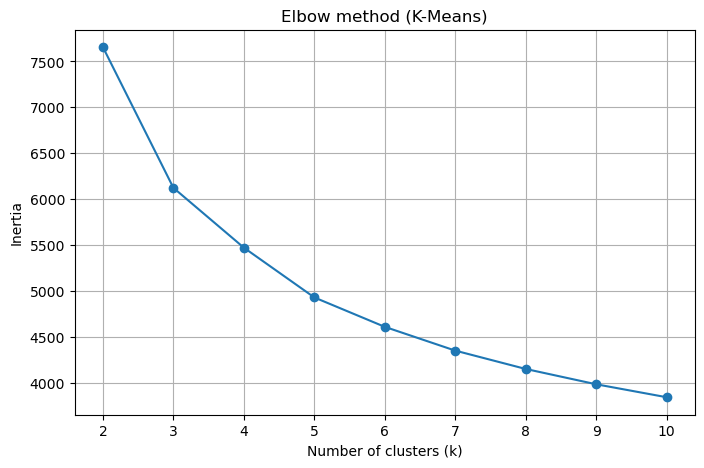

In [16]:
# assuming X_scaled is already defined
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow method (K-Means)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

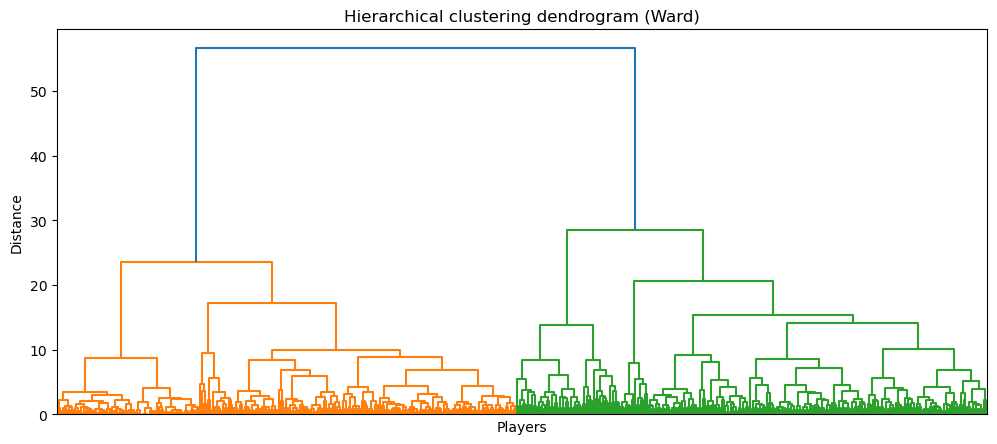

In [27]:
# 7) Hierarchical clustering (Ward linkage requires Euclidean/scaled data)
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

work_df = per_game_avg.loc[players].copy()
work_df['Cluster'] = labels_hc



# 8) Dendrogram (optional)
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, no_labels=True, color_threshold=None)
plt.title('Hierarchical clustering dendrogram (Ward)')
plt.xlabel('Players')
plt.ylabel('Distance')
plt.show()

In [18]:
cluster_means = work_df.groupby('Cluster').mean()
print(cluster_means[['PTS','AST','DRB','BLK','GmSc']])

               PTS       AST       DRB       BLK       GmSc
Cluster                                                    
0         8.720905  2.045352  3.026514  0.509822   7.366162
1        20.771343  4.628416  4.571009  0.575850  15.776138
2         2.356953  0.593469  1.009467  0.183955   1.838750


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) Assign roles per player
pts_thr = work_df['PTS'].quantile(0.50)
ast_thr = work_df['AST'].quantile(0.50)
drb_thr = work_df['DRB'].quantile(0.50)
blk_thr = work_df['BLK'].quantile(0.50)

def assign_role(row):
    if row['PTS'] > pts_thr and row['AST'] > ast_thr:
        return 'Attacking Playmaker'
    elif row['PTS'] > pts_thr:
        return 'Elite Scorer'
    elif row['AST'] > ast_thr:
        return 'Playmaker'
    elif row['DRB'] > drb_thr or row['BLK'] > blk_thr:
        return 'Defensive Specialist'
    else:
        return 'Role Player'

work_df['Role'] = work_df.apply(assign_role, axis=1)

# 2) Run PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3) Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PCA1','PCA2'], index=players)
pca_df['Cluster'] = work_df['Cluster']   # if you have cluster labels
pca_df['Role'] = work_df['Role']         # align roles by player index

print(work_df['Role'].value_counts())

Role
Attacking Playmaker     200
Role Player             130
Defensive Specialist     70
Elite Scorer             48
Playmaker                48
Name: count, dtype: int64


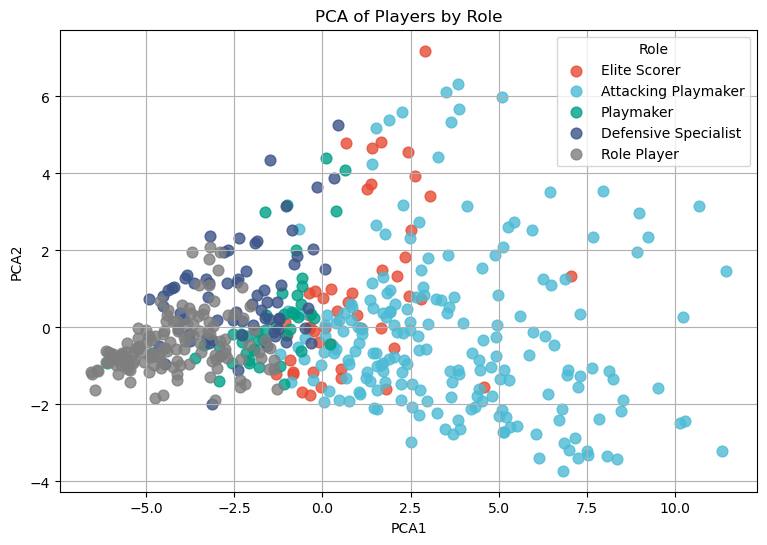

In [20]:
role_palette = {
    'Elite Scorer': '#E64B35',
    'Attacking Playmaker': '#4DBBD5',
    'Playmaker': '#00A087',
    'Defensive Specialist': '#3C5488',
    'Role Player': '#7E7E7E'
}

plt.figure(figsize=(9,6))
for role, color in role_palette.items():
    subset = pca_df[pca_df['Role'] == role]
    plt.scatter(subset['PCA1'], subset['PCA2'], c=color, label=role, alpha=0.8, s=60)

plt.title('PCA of Players by Role')
plt.xlabel('PCA1'); plt.ylabel('PCA2')
plt.legend(title='Role')
plt.grid(True)
plt.show()

In [21]:
features = [
    'FGA', 'TRB', 'AST', 'STL', 'BLK', 'PTS', 
    'points per mintues', 'shooting percentage', "successful_steals"
]
X = per_game_avg[features] 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
Ks = [2, 3, 4, 5, 6, 7]
inertias = []
print("--- Silhouette Scores ---")
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    inertias.append(kmeans.inertia_)
    print(f"k = {k}, silhouette = {score:.4f}")

--- Silhouette Scores ---
k = 2, silhouette = 0.3365
k = 3, silhouette = 0.2606


c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k = 4, silhouette = 0.2324
k = 5, silhouette = 0.2171
k = 6, silhouette = 0.2190


c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


k = 7, silhouette = 0.2161


In [23]:
# --- 1. CLUSTERING (Creates the 'cluster' column) ---
 
# Choose K=3 based on your analysis
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
 
# THIS LINE CREATES THE 'cluster' COLUMN in player_data
per_game_avg["cluster"] = kmeans.fit_predict(X_scaled)
 
 
# --- 2. INTERPRETATION (Calculates mean stats for the 3 groups) ---
 
# Define the features list again (or ensure it's defined in a previous cell)
features = [
    'FGA', 'TRB', 'AST', 'STL', 'BLK', 'PTS', 
    'points per mintues', 'shooting percentage', "successful_steals"
]
 
# Calculate the mean stats for each cluster
cluster_means = per_game_avg.groupby('cluster')[features].mean().round(2)
 
print("--- Cluster Statistics (Mean Values) ---")
print(cluster_means)

--- Cluster Statistics (Mean Values) ---
           FGA   TRB   AST   STL   BLK    PTS  points per mintues  \
cluster                                                             
0        15.79  6.16  5.15  1.18  0.62  20.77                0.63   
1         2.83  1.63  0.79  0.30  0.18   3.17                0.31   
2         7.94  4.57  2.13  0.86  0.59  10.11                0.42   

         shooting percentage  successful_steals  
cluster                                          
0                       0.50              -0.51  
1                       0.32              -0.00  
2                       0.49              -0.36  


c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


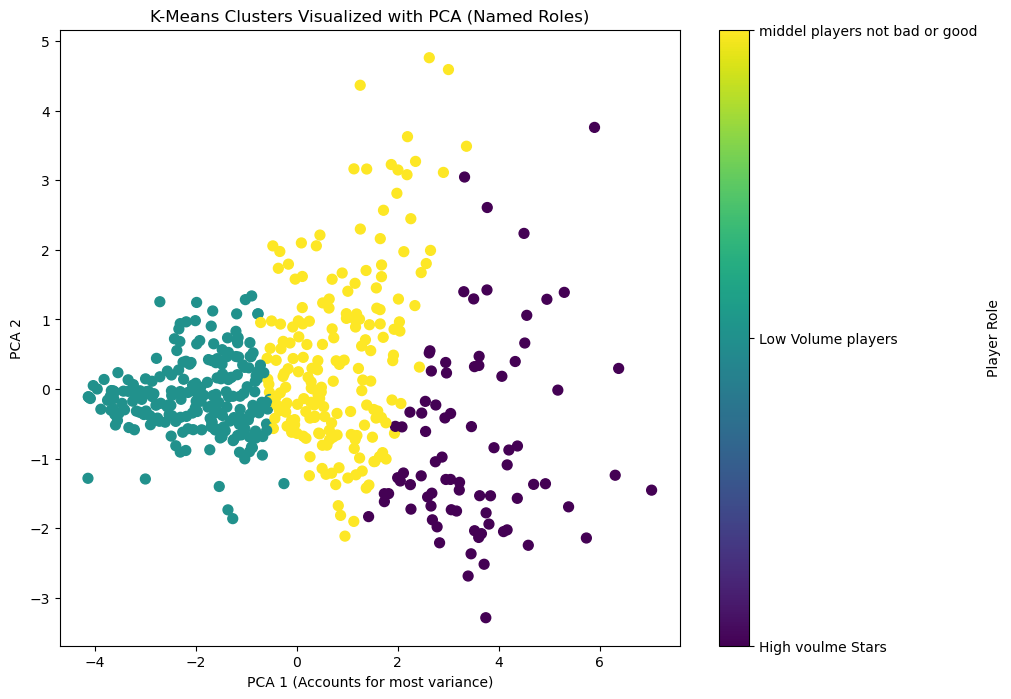

In [24]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
cluster_names = {
    0: "High voulme Stars",
    1: "Low Volume players",
    2: "middel players not bad or good "
}
 
per_game_avg["pca1"] = pca_result[:, 0]
per_game_avg["pca2"] = pca_result[:, 1]
 
plt.figure(figsize=(10, 8))
 
# Store the scatter plot object
scatter = plt.scatter(
    per_game_avg["pca1"], 
    per_game_avg["pca2"], 
    c=per_game_avg["cluster"], 
    cmap='viridis',
    s=50 # Set point size
)
 
# Add the color bar with NUMERICAL ticks
cbar = plt.colorbar(scatter, ticks=[0, 1,2], label='Player Role')
 
# CRITICAL STEP: Replace numerical ticks with descriptive names
cbar.ax.set_yticklabels([
    cluster_names[0], 
    cluster_names[1],
    cluster_names[2]
])
 
plt.xlabel("PCA 1 (Accounts for most variance)")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters Visualized with PCA (Named Roles)")
plt.show()

## -----------------------------------------------------------------------------------------------------------------
##                                          Phase 2:   task3
## ----------------------------------------------------------------------------------------------------------------- 


## Using SVM

In [28]:
## get data again making the "Res" as target
y_c = data['Res']
X_c = data.drop(['Res'], axis=1)

## drop samples with missing values
X_c = X_c.dropna()

# use the same samples
y_c = y_c[X_c.index] 

## drop categorical columns
cat_cols = ['Player', 'Tm', 'Opp', 'Data']
X_no_cat = X_c.drop(columns=cat_cols)


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_no_cat, y_c, test_size=0.20, random_state=42
)

# Encode target labels
le = LabelEncoder()
y_train=le.fit_transform(y_train)
y_test = le.fit_transform(y_test)     # W/L → 1/0
y_pred = le.fit_transform(y_pred)

# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)




In [29]:
## train SVM model
svm_classifier = SVC( kernel='rbf',  C=200  ,  gamma=0.0005  , random_state=42)
svm_classifier.fit(X_train_scaled, y_train)

print(y_c.value_counts())
print(y_c.value_counts(normalize=True))

Res
L    3617
W    3602
Name: count, dtype: int64
Res
L    0.501039
W    0.498961
Name: proportion, dtype: float64


accuracy: 0.5754847645429363  precision: 0.5665760869565217   recall: 0.5864978902953587   f1_score: 0.5763648928818245  ROC: 0.5756500365528636


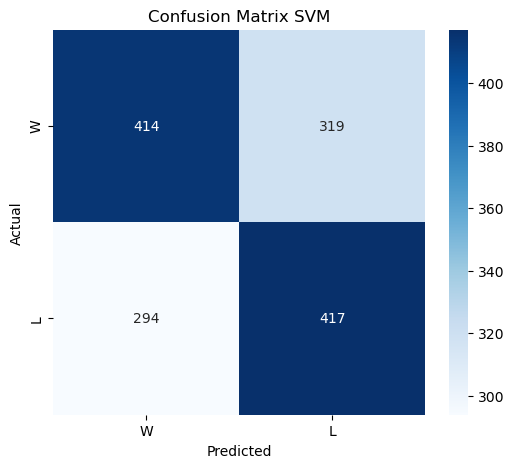

In [31]:
## the calses are balanced no need to handle anything 

## predect and encode
y_pred = svm_classifier.predict(X_test_scaled)
y_pred = le.fit_transform(y_pred)


## Testing mathods
A_s = accuracy_score(y_test, y_pred)
P_s = precision_score(y_test , y_pred , pos_label=1)
CM_s = confusion_matrix(y_test ,y_pred )
RS_s = recall_score(y_test , y_pred , pos_label=1)
F1_s = f1_score(y_test , y_pred , pos_label=1)
roc_s = roc_auc_score(y_test, y_pred)

print("accuracy: {}  precision: {}   recall: {}   f1_score: {}  ROC: {}".format(A_s , P_s, RS_s, F1_s, roc_s))

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(CM_s, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['W','L'], yticklabels=['W','L'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix SVM')
plt.show()

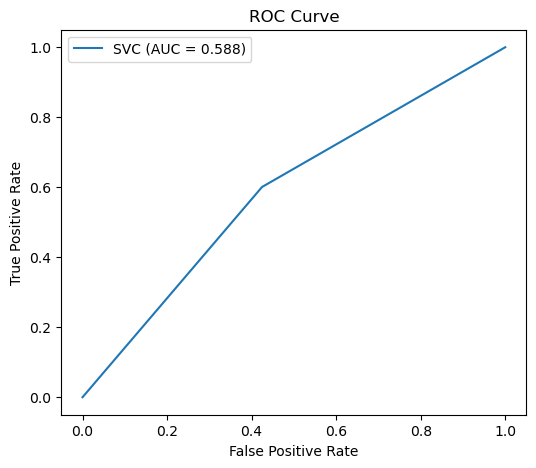

In [78]:
# ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'SVC (AUC = {roc_s:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [79]:
# Train Random Forest model
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_classifier.fit(X_train_scaled, y_train)

# Predict (now predictions are 0/1)
y_pred = rf_classifier.predict(X_test_scaled)
y_proba = rf_classifier.predict_proba(X_test_scaled)[:, 1]
# -----------------------------
# Evaluation metrics
# -----------------------------

print(
    "accuracy: {}  precision: {}   recall: {}   f1_score: {}  ROC: {}".format(
        A_s, P_s, RS_s, F1_s, roc_s
    )
)

accuracy: 0.5878255602665051  precision: 0.5781990521327014   recall: 0.6006153846153847   f1_score: 0.5891940839118623  ROC: 0.5880238521168755


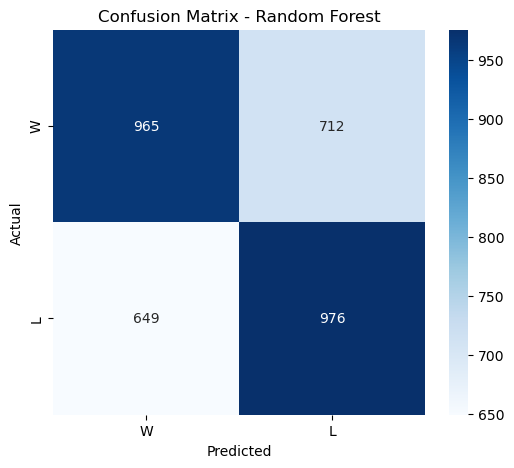

In [80]:
plt.figure(figsize=(6,5))
sns.heatmap(
    CM_s,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['W','L'],
    yticklabels=['W','L']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

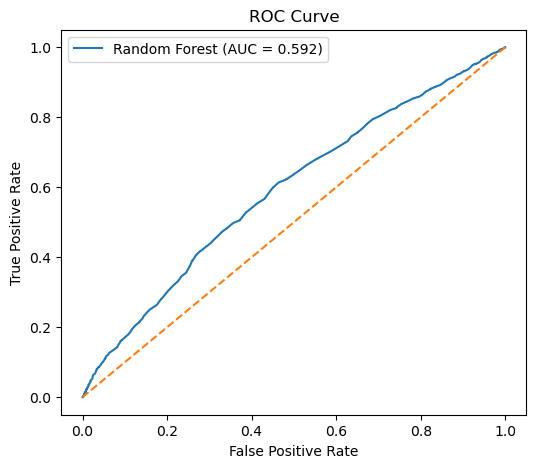

In [81]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Using Decision Tree  

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
y_test_dt=y_test

dt_model = DecisionTreeClassifier(random_state=45)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None]
}

grid = GridSearchCV(
    dt_model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=45),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 8, 10, None]},
             scoring='accuracy')

In [35]:
best_dt = grid.best_estimator_


In [36]:
y_pred  = best_dt.predict(X_test)
y_proba = best_dt.predict_proba(X_test)[:, 1]

In [37]:
y_pred_dt  = best_dt.predict(X_test_scaled)
y_proba_dt = best_dt.predict_proba(X_test_scaled)[:, 1]
print("Accuracy :", accuracy_score(y_test_dt, y_pred_dt))
print("Precision:", precision_score(y_test_dt, y_pred_dt))
print("Recall   :", recall_score(y_test_dt, y_pred_dt))
print("F1-score :", f1_score(y_test_dt, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test_dt, y_proba_dt))


Accuracy : 0.47991689750692523
Precision: 0.4831365935919056
Recall   : 0.8059071729957806
F1-score : 0.6041117554032683
ROC-AUC  : 0.4783896784691161


c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\abdou\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[[120 613]
 [138 573]]


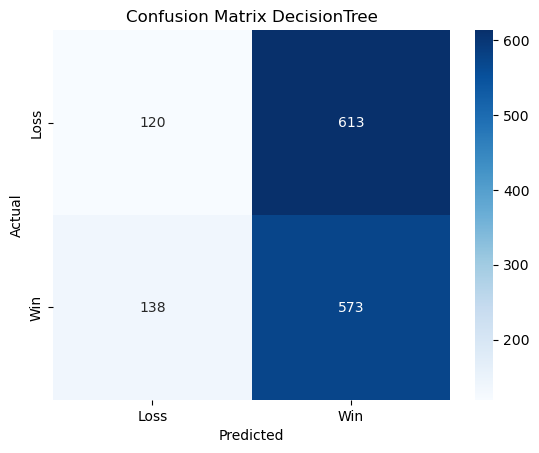

In [38]:


cm = confusion_matrix(y_test, y_pred_dt)
cm_pd = pd.DataFrame(cm)
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Loss", "Win"],
    yticklabels=["Loss", "Win"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix DecisionTree")
plt.show()

## Logistic Regression


In [39]:
from sklearn.linear_model import LogisticRegression


Task3 = LogisticRegression(max_iter=500)
Task3.fit(X_train,y_train)
Task3_predict= Task3.predict(X_test)
print("Accuracy :" , accuracy_score(y_test,Task3_predict))

Accuracy : 0.5734072022160664


In [40]:
from sklearn.metrics import roc_curve, roc_auc_score , precision_score, recall_score, f1_score , classification_report

y_prob = Task3.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)


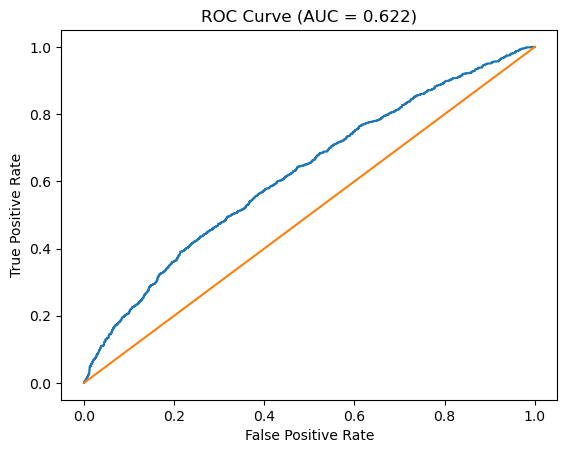

In [118]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.3f})")
plt.show()


In [41]:
precision = precision_score(y_test, Task3_predict)
recall = recall_score(y_test, Task3_predict)
f1 = f1_score(y_test, Task3_predict)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print(classification_report(y_test, Task3_predict))

Precision: 0.5668073136427567
Recall: 0.5668073136427567
F1-score: 0.5668073136427567
              precision    recall  f1-score   support

           0       0.58      0.58      0.58       733
           1       0.57      0.57      0.57       711

    accuracy                           0.57      1444
   macro avg       0.57      0.57      0.57      1444
weighted avg       0.57      0.57      0.57      1444



In [42]:
cm = confusion_matrix(y_test, Task3_predict)
cm_pd = pd.DataFrame(cm)
print(cm)


[[425 308]
 [308 403]]


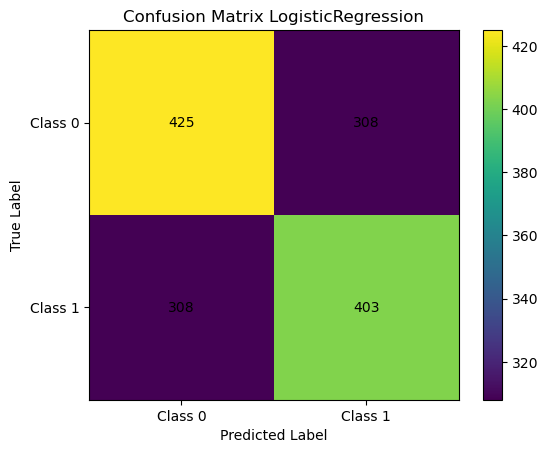

class 0 and 1 FP , class 0 and 0 TN , class 1 and 1 TP, class 1 and 0 FN


In [43]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix LogisticRegression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

plt.show()
print("class 0 and 1 FP , class 0 and 0 TN , class 1 and 1 TP, class 1 and 0 FN")